# Project 3: Topologically-Constrained Multi-Task Learning for Periodontitis Grading

**Course:** Computer Vision A.A. 2025–2026  
**Project:** Periodontitis Grading  
**Framework:** PyTorch  
**Environment:** Google Colab with GPU

## Objective

This notebook implements a multi-task deep learning pipeline for periodontitis grading using intra-oral dental radiographs.

The model performs two tasks:

1. **Radiograph-wise segmentation**
2. **Periodontitis grade classification**

The proposed methodological novelty is an **Anatomical Consistency Loss**, which constrains the predicted periodontitis grade using the CEJ–Bone anatomical distance extracted from clinical annotations.

# 1. Imports

This section contains all required Python packages.

In [1]:
import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import Subset

from google.colab import drive

# 2. Globals

This section contains global paths, hyperparameters, and device configuration.

Before running the notebook, enable GPU in Colab:

**Runtime → Change runtime type → Hardware accelerator → T4 GPU**

In [2]:
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/CompVision_Project-3/"

TRAIN_DIR = BASE_DIR + "Training/"
VAL_DIR = BASE_DIR + "Validation/"
TEST_DIR = BASE_DIR + "Testing/"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 2
NUM_EPOCHS = 4
LEARNING_RATE = 1e-4

IMG_SIZE = 256

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


# 3. Utils

Helper functions for reading annotations, computing anatomical distances, generating weak grading labels, and visualizing samples.

In [3]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def point_to_polyline_distance(point, polyline):
    point = np.array(point)
    polyline = np.array(polyline)
    distances = np.linalg.norm(polyline - point, axis=1)
    return distances.min()


def compute_cej_bone_distance(keypoints, bone):
    cej_points = keypoints["CEJ_Points"]
    bone_lines = bone["Bone_Lines"]

    distances = []

    for cej in cej_points:
        min_dist = min(
            point_to_polyline_distance(cej, line)
            for line in bone_lines
        )
        distances.append(min_dist)

    return float(np.mean(distances)), distances


def distance_to_grade(distance):
    if distance < 20:
        return 0
    elif distance < 50:
        return 1
    else:
        return 2


def visualize_sample(root_dir, sample_id):
    img_path = os.path.join(root_dir, "Images", sample_id + ".jpg")
    keypoints_path = os.path.join(root_dir, "Key Points Annotations", sample_id + ".json")
    bone_path = os.path.join(root_dir, "Bone Level Annotations", sample_id + ".json")

    image = Image.open(img_path).convert("RGB")
    keypoints = load_json(keypoints_path)
    bone = load_json(bone_path)

    mean_distance, _ = compute_cej_bone_distance(keypoints, bone)
    grade = distance_to_grade(mean_distance)

    plt.figure(figsize=(10, 8))
    plt.imshow(image, cmap="gray")

    cej = np.array(keypoints["CEJ_Points"])
    plt.scatter(cej[:, 0], cej[:, 1], s=40, label="CEJ points")

    for line in bone["Bone_Lines"]:
        line = np.array(line)
        plt.plot(line[:, 0], line[:, 1], linewidth=2, label="Bone line")

    plt.title(f"Sample {sample_id}: CEJ-Bone distance={mean_distance:.2f}, Grade={grade}")
    plt.legend()
    plt.axis("off")
    plt.show()

# 4. Data Exploration

We verify that the dataset is correctly mounted and inspect one annotated sample.

In [4]:
def count_files(folder):
    if not os.path.exists(folder):
        print("Not found:", folder)
        return 0
    return len([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ])

print("Training folder:")
print(os.listdir(TRAIN_DIR))

print("\nNumber of training images:")
print(count_files(os.path.join(TRAIN_DIR, "Images")))

print("\nNumber of radiograph-wise masks:")
print(count_files(os.path.join(TRAIN_DIR, "Masks (Radiograph-wise)")))

print("\nNumber of keypoint annotations:")
print(count_files(os.path.join(TRAIN_DIR, "Key Points Annotations")))

print("\nNumber of bone level annotations:")
print(count_files(os.path.join(TRAIN_DIR, "Bone Level Annotations")))

Training folder:
['Images', 'Key Points Annotations', 'Masks (Radiograph-wise)', 'Bone Level Annotations', 'Masks (Tooth-wise)']

Number of training images:
651

Number of radiograph-wise masks:
650

Number of keypoint annotations:
650

Number of bone level annotations:
651


Image exists: True
Mask exists: True
Keypoints exists: True
Bone annotation exists: True
Image size: (1168, 883)
Mask size: (1168, 883)
Mask unique values: [  0 255]


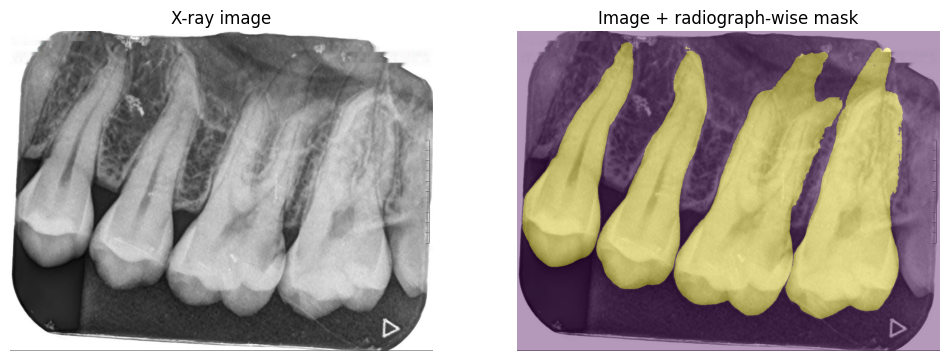

In [5]:
sample_id = "1014"

img_path = TRAIN_DIR + f"Images/{sample_id}.jpg"
mask_path = TRAIN_DIR + f"Masks (Radiograph-wise)/{sample_id}.png"
keypoints_path = TRAIN_DIR + f"Key Points Annotations/{sample_id}.json"
bone_path = TRAIN_DIR + f"Bone Level Annotations/{sample_id}.json"

print("Image exists:", os.path.exists(img_path))
print("Mask exists:", os.path.exists(mask_path))
print("Keypoints exists:", os.path.exists(keypoints_path))
print("Bone annotation exists:", os.path.exists(bone_path))

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

print("Image size:", img.size)
print("Mask size:", mask.size)
print("Mask unique values:", np.unique(np.array(mask)))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("X-ray image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.4)
plt.title("Image + radiograph-wise mask")
plt.axis("off")

plt.show()

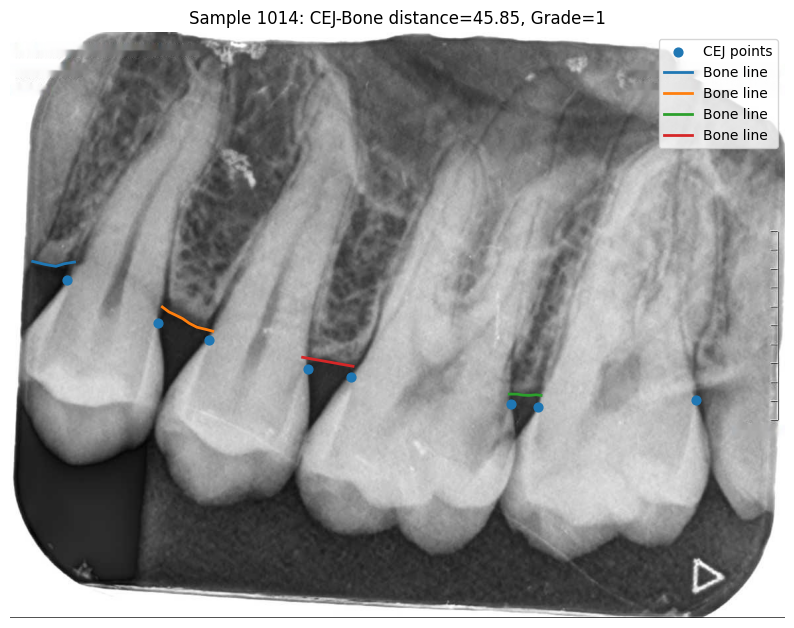

In [ ]:
visualize_sample(TRAIN_DIR, "1014")

# 5. Data

This section defines a custom PyTorch Dataset for DenPAR.

Each sample returns:

- image tensor
- radiograph-wise binary mask
- weak periodontitis grade derived from CEJ–Bone distance
- anatomical distance used for the proposed constraint

In [6]:
class DenPARDataset(Dataset):
    def __init__(self, root_dir, img_size=256):
        self.root_dir = root_dir
        self.img_size = img_size

        self.images_dir = os.path.join(root_dir, "Images")
        self.masks_dir = os.path.join(root_dir, "Masks (Radiograph-wise)")
        self.keypoints_dir = os.path.join(root_dir, "Key Points Annotations")
        self.bone_dir = os.path.join(root_dir, "Bone Level Annotations")

        image_files = sorted([
            f for f in os.listdir(self.images_dir)
            if f.endswith(".jpg")
        ])

        self.ids = []

        for img_file in image_files:
            sample_id = img_file.replace(".jpg", "")

            mask_path = os.path.join(self.masks_dir, sample_id + ".png")
            keypoints_path = os.path.join(self.keypoints_dir, sample_id + ".json")
            bone_path = os.path.join(self.bone_dir, sample_id + ".json")

            if (
                os.path.exists(mask_path)
                and os.path.exists(keypoints_path)
                and os.path.exists(bone_path)
            ):
                self.ids.append(sample_id)

        print(f"Loaded {len(self.ids)} valid samples from {root_dir}")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        img_path = os.path.join(self.images_dir, sample_id + ".jpg")
        mask_path = os.path.join(self.masks_dir, sample_id + ".png")
        keypoints_path = os.path.join(self.keypoints_dir, sample_id + ".json")
        bone_path = os.path.join(self.bone_dir, sample_id + ".json")

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        keypoints = load_json(keypoints_path)
        bone = load_json(bone_path)

        mean_distance, _ = compute_cej_bone_distance(keypoints, bone)
        grade = distance_to_grade(mean_distance)

        image = image.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size))

        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32) / 255.0

        image = torch.tensor(image).permute(2, 0, 1)
        mask = torch.tensor(mask).unsqueeze(0)

        grade = torch.tensor(grade, dtype=torch.long)
        distance = torch.tensor(mean_distance, dtype=torch.float32)

        return image, mask, grade, distance

In [7]:
train_dataset = DenPARDataset(TRAIN_DIR, img_size=IMG_SIZE)
val_dataset = DenPARDataset(VAL_DIR, img_size=IMG_SIZE)
test_dataset = DenPARDataset(TEST_DIR, img_size=IMG_SIZE)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Loaded 650 valid samples from /content/drive/MyDrive/Colab_Notebooks/CompVision_Project-3/Training/
Loaded 150 valid samples from /content/drive/MyDrive/Colab_Notebooks/CompVision_Project-3/Validation/
Loaded 200 valid samples from /content/drive/MyDrive/Colab_Notebooks/CompVision_Project-3/Testing/
Train: 650
Validation: 150
Test: 200


In [8]:
image, mask, grade, distance = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Grade:", grade.item())
print("Distance:", distance.item())

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Grade: 2
Distance: 212.03285217285156


# 6. DataLoader

We create PyTorch DataLoaders for training, validation, and testing.

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

images, masks, grades, distances = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Grades:", grades)
print("Distances:", distances)

Images: torch.Size([2, 3, 256, 256])
Masks: torch.Size([2, 1, 256, 256])
Grades: tensor([2, 2])
Distances: tensor([ 78.6433, 101.7017])


# 7. Data Analysis

The generated weak grades are imbalanced. We analyze the class distribution before training.

In [10]:
def get_grade_distribution(dataset):
    grades = []

    for i in range(len(dataset)):
        _, _, grade, _ = dataset[i]
        grades.append(grade.item())

    return Counter(grades)


train_dist = get_grade_distribution(train_dataset)
val_dist = get_grade_distribution(val_dataset)
test_dist = get_grade_distribution(test_dataset)

print("Train distribution:", train_dist)
print("Validation distribution:", val_dist)
print("Test distribution:", test_dist)

Train distribution: Counter({2: 463, 1: 178, 0: 9})
Validation distribution: Counter({2: 105, 1: 42, 0: 3})
Test distribution: Counter({2: 142, 1: 55, 0: 3})


# 8. Network

We implement a baseline multi-task U-Net with:

- shared convolutional encoder
- segmentation decoder
- classification head

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class MultiTaskUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.segmentation_head = nn.Conv2d(32, 1, kernel_size=1)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classification_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        class_logits = self.classification_head(self.global_pool(b))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        mask_logits = self.segmentation_head(d1)

        return mask_logits, class_logits

In [12]:
model = MultiTaskUNet(num_classes=3).to(DEVICE)

images, masks, grades, distances = next(iter(train_loader))
images = images.to(DEVICE)

mask_logits, class_logits = model(images)

print("Mask logits shape:", mask_logits.shape)
print("Class logits shape:", class_logits.shape)

Mask logits shape: torch.Size([2, 1, 256, 256])
Class logits shape: torch.Size([2, 3])


# 9. Train

The baseline model is trained with:

- Binary Cross Entropy with logits for segmentation
- Weighted Cross Entropy for classification

Class weights are used because the weak grading labels are highly imbalanced.

In [13]:
class_weights = torch.tensor([20.0, 3.0, 1.0]).to(DEVICE)

segmentation_loss_fn = nn.BCEWithLogitsLoss()
classification_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

model = MultiTaskUNet(num_classes=3).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [14]:
def train_one_epoch(model, dataloader, optimizer):
    model.train()

    total_loss = 0
    total_seg_loss = 0
    total_cls_loss = 0

    for images, masks, grades, distances in dataloader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        grades = grades.to(DEVICE)

        optimizer.zero_grad()

        mask_logits, class_logits = model(images)

        seg_loss = segmentation_loss_fn(mask_logits, masks)
        cls_loss = classification_loss_fn(class_logits, grades)

        loss = seg_loss + cls_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_seg_loss += seg_loss.item()
        total_cls_loss += cls_loss.item()

    n = len(dataloader)

    return {
        "loss": total_loss / n,
        "seg_loss": total_seg_loss / n,
        "cls_loss": total_cls_loss / n
    }


def evaluate(model, dataloader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, masks, grades, distances in dataloader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            grades = grades.to(DEVICE)

            mask_logits, class_logits = model(images)

            seg_loss = segmentation_loss_fn(mask_logits, masks)
            cls_loss = classification_loss_fn(class_logits, grades)

            loss = seg_loss + cls_loss
            total_loss += loss.item()

            preds = torch.argmax(class_logits, dim=1)
            correct += (preds == grades).sum().item()
            total += grades.size(0)

    return {
        "val_loss": total_loss / len(dataloader),
        "val_accuracy": correct / total
    }

# 10. Baseline Training

This is the baseline multi-task model without anatomical consistency loss.

In [15]:
history_baseline = []

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, optimizer)
    val_metrics = evaluate(model, val_loader)

    print(f"Epoch {epoch + 1}")
    print(train_metrics)
    print(val_metrics)

    history_baseline.append({
        **train_metrics,
        **val_metrics
    })

torch.save(model.state_dict(), BASE_DIR + "baseline_multitask_unet.pth")
print("Baseline model saved.")

Epoch 1
{'loss': 1.2110396537413963, 'seg_loss': 0.37945832793529216, 'cls_loss': 0.8315813234219185}
{'val_loss': 1.0870374818642934, 'val_accuracy': 0.7}
Epoch 2
{'loss': 1.0074609820659344, 'seg_loss': 0.26149334957966436, 'cls_loss': 0.7459676345495078}
{'val_loss': 0.9647894887129466, 'val_accuracy': 0.6933333333333334}
Epoch 3
{'loss': 0.9633392275296725, 'seg_loss': 0.21652115088242752, 'cls_loss': 0.74681807747254}
{'val_loss': 0.9215905606746674, 'val_accuracy': 0.7066666666666667}
Epoch 4
{'loss': 0.9211419153213501, 'seg_loss': 0.18812603450738466, 'cls_loss': 0.7330158815934108}
{'val_loss': 0.8881636921564738, 'val_accuracy': 0.74}
Baseline model saved.


# 11. Proposed Method

## Anatomical Consistency Loss

The proposed method introduces a constraint between the predicted grade and the CEJ–Bone distance.

The model predicts a soft grade from class probabilities. This soft grade is penalized when it is inconsistent with the anatomical grade derived from CEJ–Bone distance.

In [16]:
def anatomical_consistency_loss(class_logits, distances):
    probs = torch.softmax(class_logits, dim=1)

    grade_values = torch.tensor(
        [0.0, 1.0, 2.0],
        device=DEVICE
    )

    predicted_grade = torch.sum(
        probs * grade_values,
        dim=1
    )

    anatomical_grade = torch.zeros_like(distances).to(DEVICE)

    anatomical_grade[distances < 20] = 0.0
    anatomical_grade[(distances >= 20) & (distances < 50)] = 1.0
    anatomical_grade[distances >= 50] = 2.0

    return torch.mean(
        (predicted_grade - anatomical_grade) ** 2
    )


def train_one_epoch_constrained(model, dataloader, optimizer, lambda_anat=0.5):
    model.train()

    total_loss = 0
    total_seg_loss = 0
    total_cls_loss = 0
    total_anat_loss = 0

    for images, masks, grades, distances in dataloader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        grades = grades.to(DEVICE)
        distances = distances.to(DEVICE)

        optimizer.zero_grad()

        mask_logits, class_logits = model(images)

        seg_loss = segmentation_loss_fn(mask_logits, masks)
        cls_loss = classification_loss_fn(class_logits, grades)
        anat_loss = anatomical_consistency_loss(class_logits, distances)

        loss = seg_loss + cls_loss + lambda_anat * anat_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_seg_loss += seg_loss.item()
        total_cls_loss += cls_loss.item()
        total_anat_loss += anat_loss.item()

    n = len(dataloader)

    return {
        "loss": total_loss / n,
        "seg_loss": total_seg_loss / n,
        "cls_loss": total_cls_loss / n,
        "anat_loss": total_anat_loss / n
    }

# 12. Proposed Model Training

This model uses the same architecture as the baseline, but adds the Anatomical Consistency Loss.

In [17]:
constrained_model = MultiTaskUNet(num_classes=3).to(DEVICE)

optimizer_constrained = optim.Adam(
    constrained_model.parameters(),
    lr=LEARNING_RATE
)

history_constrained = []

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch_constrained(
        constrained_model,
        train_loader,
        optimizer_constrained,
        lambda_anat=0.5
    )

    val_metrics = evaluate(constrained_model, val_loader)

    print(f"Epoch {epoch + 1}")
    print(train_metrics)
    print(val_metrics)

    history_constrained.append({
        **train_metrics,
        **val_metrics
    })

torch.save(constrained_model.state_dict(), BASE_DIR + "constrained_multitask_unet.pth")
print("Constrained model saved.")

Epoch 1
{'loss': 1.3794938555130591, 'seg_loss': 0.3867713374357957, 'cls_loss': 0.831846414070863, 'anat_loss': 0.3217522086059818}
{'val_loss': 1.0690528615315755, 'val_accuracy': 0.6933333333333334}
Epoch 2
{'loss': 1.141037116600917, 'seg_loss': 0.26495781990197986, 'cls_loss': 0.7554424577492934, 'anat_loss': 0.24127368369927774}
{'val_loss': 0.9805789077281952, 'val_accuracy': 0.6666666666666666}
Epoch 3
{'loss': 1.072869290663646, 'seg_loss': 0.22095181708152478, 'cls_loss': 0.7348458900818458, 'anat_loss': 0.23414316028356552}
{'val_loss': 0.9085183648268381, 'val_accuracy': 0.6866666666666666}
Epoch 4
{'loss': 1.0537006363501915, 'seg_loss': 0.19728999007206696, 'cls_loss': 0.7396446323394775, 'anat_loss': 0.23353202790021896}
{'val_loss': 0.9632379833857219, 'val_accuracy': 0.7}
Constrained model saved.


# 13. Evaluation

We evaluate classification predictions and segmentation quality.

In [18]:
def get_predictions(model, dataloader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks, grades, distances in dataloader:
            images = images.to(DEVICE)
            grades = grades.to(DEVICE)

            _, class_logits = model(images)
            preds = torch.argmax(class_logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(grades.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


def classification_accuracy(labels, preds):
    return (labels == preds).mean()


def confusion_matrix_numpy(labels, preds, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(labels, preds):
        cm[int(true_label), int(pred_label)] += 1

    return cm


def dice_score_from_logits(mask_logits, masks, threshold=0.5):
    probs = torch.sigmoid(mask_logits)
    preds = (probs > threshold).float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + 1e-7) / (union + 1e-7)
    return dice.mean().item()


def iou_score_from_logits(mask_logits, masks, threshold=0.5):
    probs = torch.sigmoid(mask_logits)
    preds = (probs > threshold).float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + 1e-7) / (union + 1e-7)
    return iou.mean().item()


def evaluate_segmentation(model, dataloader):
    model.eval()

    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for images, masks, grades, distances in dataloader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            mask_logits, _ = model(images)

            dice_scores.append(dice_score_from_logits(mask_logits, masks))
            iou_scores.append(iou_score_from_logits(mask_logits, masks))

    return {
        "dice": float(np.mean(dice_scores)),
        "iou": float(np.mean(iou_scores))
    }

In [19]:
baseline_labels, baseline_preds = get_predictions(model, val_loader)
constrained_labels, constrained_preds = get_predictions(constrained_model, val_loader)

print("Validation labels:", Counter(baseline_labels))

print("\nBaseline predictions:", Counter(baseline_preds))
print("Baseline accuracy:", classification_accuracy(baseline_labels, baseline_preds))
print("Baseline confusion matrix:")
print(confusion_matrix_numpy(baseline_labels, baseline_preds))

print("\nConstrained predictions:", Counter(constrained_preds))
print("Constrained accuracy:", classification_accuracy(constrained_labels, constrained_preds))
print("Constrained confusion matrix:")
print(confusion_matrix_numpy(constrained_labels, constrained_preds))

baseline_seg = evaluate_segmentation(model, val_loader)
constrained_seg = evaluate_segmentation(constrained_model, val_loader)

print("\nBaseline segmentation:", baseline_seg)
print("Constrained segmentation:", constrained_seg)

Validation labels: Counter({np.int64(2): 105, np.int64(1): 42, np.int64(0): 3})

Baseline predictions: Counter({np.int64(2): 115, np.int64(1): 35})
Baseline accuracy: 0.74
Baseline confusion matrix:
[[ 0  1  2]
 [ 0 20 22]
 [ 0 14 91]]

Constrained predictions: Counter({np.int64(2): 150})
Constrained accuracy: 0.7
Constrained confusion matrix:
[[  0   0   3]
 [  0   0  42]
 [  0   0 105]]

Baseline segmentation: {'dice': 0.906298619111379, 'iou': 0.8400243842601776}
Constrained segmentation: {'dice': 0.895367906888326, 'iou': 0.8231159945329031}


# 14. Ablation Study

The ablation compares:

1. **Baseline:** segmentation + classification
2. **Proposed:** segmentation + classification + anatomical consistency loss

In [20]:
ablation_results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Description": "Segmentation + Classification",
        "Val Accuracy": classification_accuracy(baseline_labels, baseline_preds),
        "Dice": baseline_seg["dice"],
        "IoU": baseline_seg["iou"]
    },
    {
        "Model": "Proposed",
        "Description": "Segmentation + Classification + Anatomical Consistency Loss",
        "Val Accuracy": classification_accuracy(constrained_labels, constrained_preds),
        "Dice": constrained_seg["dice"],
        "IoU": constrained_seg["iou"]
    }
])

ablation_results

,Model,Description,Val Accuracy,Dice,IoU
0,Baseline,Segmentation + Classification,0.74,0.906299,0.840024
1,Proposed,Segmentation + Classification + Anatomical Con...,0.70,0.895368,0.823116


# 15. Qualitative Visualization

We visualize predicted segmentation masks for qualitative comparison.

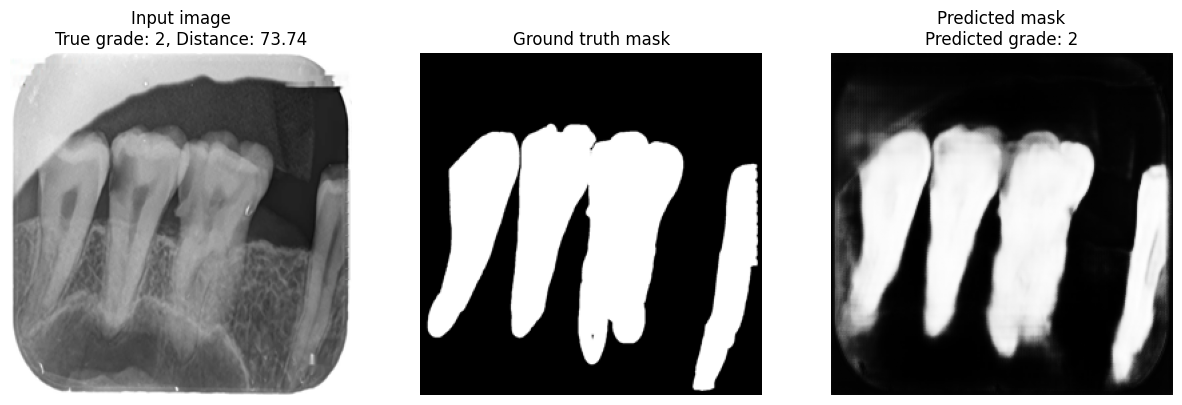

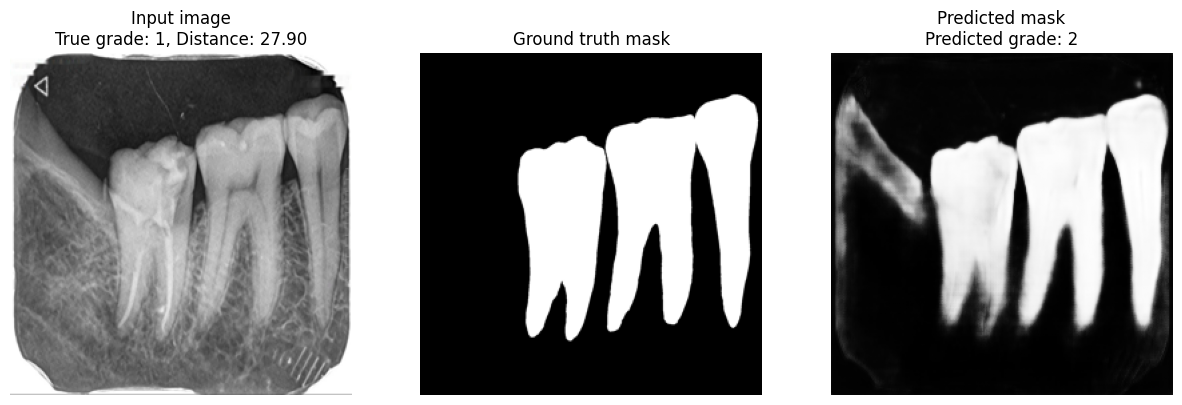

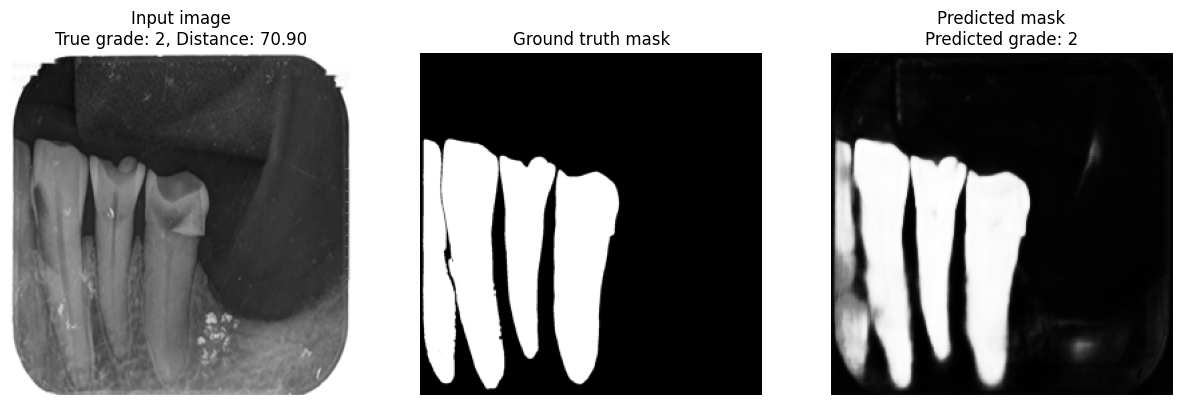

In [21]:
def visualize_prediction(model, dataset, idx=0):
    model.eval()

    image, mask, grade, distance = dataset[idx]

    with torch.no_grad():
        input_image = image.unsqueeze(0).to(DEVICE)
        mask_logits, class_logits = model(input_image)

        pred_mask = torch.sigmoid(mask_logits)[0, 0].cpu().numpy()
        pred_grade = torch.argmax(class_logits, dim=1).item()

    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask[0].numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"Input image\nTrue grade: {grade.item()}, Distance: {distance.item():.2f}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground truth mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title(f"Predicted mask\nPredicted grade: {pred_grade}")
    plt.axis("off")

    plt.show()


visualize_prediction(constrained_model, val_dataset, idx=0)
visualize_prediction(constrained_model, val_dataset, idx=1)
visualize_prediction(constrained_model, val_dataset, idx=2)

# 16. Training Curves

We plot baseline and proposed model training metrics.

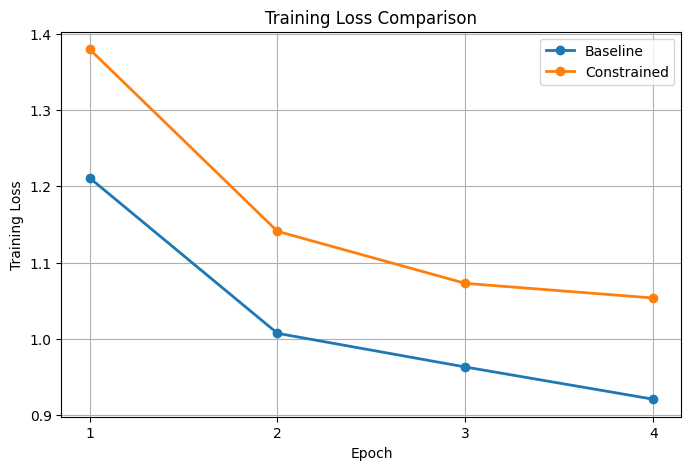

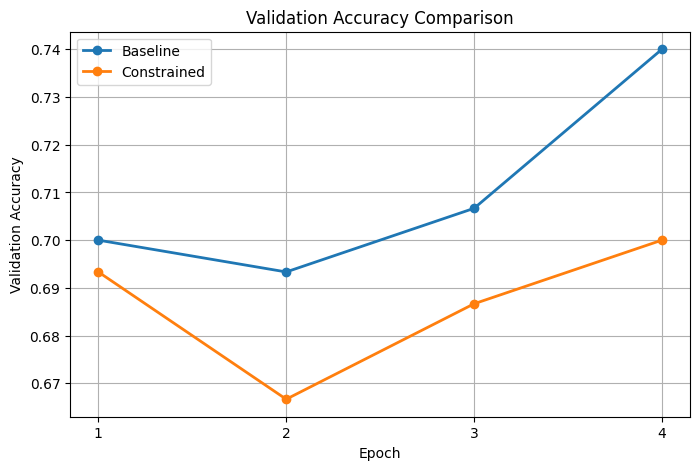

In [23]:
baseline_df = pd.DataFrame(history_baseline)
constrained_df = pd.DataFrame(history_constrained)

epochs = range(1, len(baseline_df) + 1)

# Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    baseline_df["loss"],
    marker="o",
    linewidth=2,
    label="Baseline"
)

plt.plot(
    epochs,
    constrained_df["loss"],
    marker="o",
    linewidth=2,
    label="Constrained"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.xticks(epochs)

plt.legend()
plt.grid(True)
plt.show()


# Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    baseline_df["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Baseline"
)

plt.plot(
    epochs,
    constrained_df["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Constrained"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.xticks(epochs)

plt.legend()
plt.grid(True)
plt.show()

# 17. Grad-CAM Visualization

Grad-CAM is used to visualize which regions of the radiograph contribute most to the classification decision.

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()

        mask_logits, class_logits = self.model(input_tensor)

        if target_class is None:
            target_class = torch.argmax(class_logits, dim=1).item()

        self.model.zero_grad()

        score = class_logits[:, target_class]
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, target_class

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [25]:
def visualize_gradcam(model, dataset, idx=0):
    image, mask, grade, distance = dataset[idx]

    input_tensor = image.unsqueeze(0).to(DEVICE)

    gradcam = GradCAM(
        model=model,
        target_layer=model.bottleneck
    )

    cam, pred_class = gradcam.generate(input_tensor)

    gradcam.remove_hooks()

    image_np = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"Input Image\nTrue Grade: {grade.item()}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.title(f"Grad-CAM\nPredicted Grade: {pred_class}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask[0].numpy(), cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()

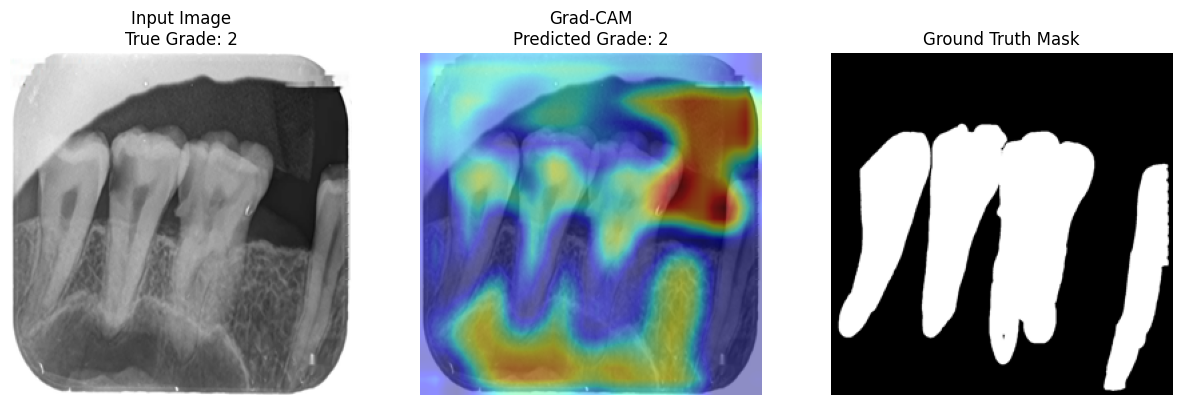

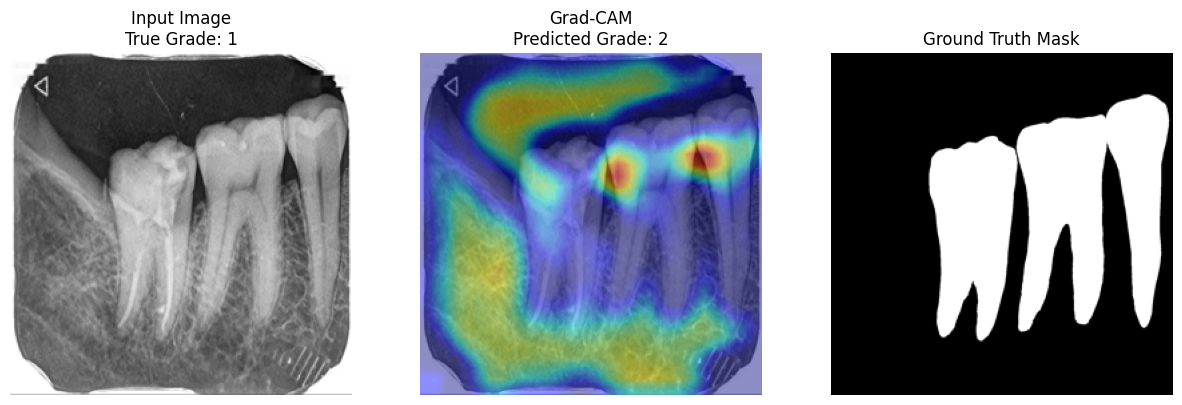

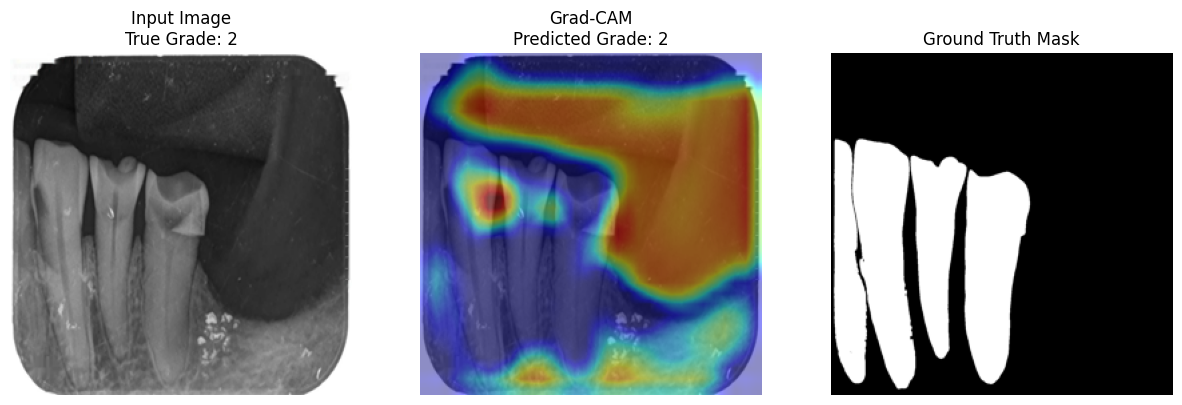

In [26]:
visualize_gradcam(constrained_model, val_dataset, idx=0)
visualize_gradcam(constrained_model, val_dataset, idx=1)
visualize_gradcam(constrained_model, val_dataset, idx=2)

# 18. Conclusions

This project implemented a multi-task model for periodontitis grading using DenPAR annotations.

## Main contributions

- Built a custom PyTorch Dataset for dental radiographs, masks, CEJ points, and bone-level annotations.
- Derived weak periodontitis grades from CEJ–Bone anatomical distance.
- Implemented a multi-task U-Net for segmentation and classification.
- Added an Anatomical Consistency Loss to constrain classification predictions using clinical anatomy.
- Compared baseline and proposed method through an ablation study.

## Limitations

- The grading labels are weak labels derived from anatomical distance, not manually assigned clinical grades.
- The dataset is highly imbalanced, especially for grade 0.
- More training epochs and stronger architectures may improve performance.

## Future work

- Use tooth-wise segmentation masks instead of radiograph-wise masks.
- Add Grad-CAM for interpretability.
- Use oversampling or focal loss to better handle class imbalance.
- Validate grading thresholds with clinical expertise.